# Visualiser la performance aux examens des étudiants avec des surfaces 3D et des nuages de points (PROC G3D)

## Synthèse

Ce notebook utilise **PROC G3D** pour visualiser comment deux facteurs
d'intervention pédagogique façonnent conjointement les résultats des
étudiants dans un contexte d'analytique éducative. Une grille factorielle
complète pilote une **surface** de réponse lisse des scores d'examen prédits
selon les heures d'étude hebdomadaires (0 à 20) et la moyenne académique
antérieure (0 à 4), et une cohorte synthétique de 100 étudiants est rendue
sous forme de panneaux de **nuage de points 3D** répartis par palier de
réussite.

La surface ajustée grimpe d'un score prédit proche de 26 à zéro heure
d'étude vers un plafond proche de 99, s'aplatissant lorsque les heures
d'étude dépassent environ 10 — la crête des rendements décroissants que le
modèle encode. Les panneaux d'étudiants confirment le schéma au niveau
individuel : les 20 étudiants *Excellent* (chacun avec un score de 85 ou
plus) se situent dans le coin à moyenne élevée et étude soutenue, tandis que
les 33 étudiants *Fragile* se concentrent dans la région à faible effort et
faible moyenne. Une vue filtrée par WHERE de ce coin isole 35 étudiants pour
lesquels des hausses modestes du temps d'étude offrent les gains marginaux
les plus importants.


## Sources de données

Toutes les données sont générées en ligne avec `call streaminit()` et
`rand()` — aucun fichier externe ni accès réseau.

**`score_grid`** — grille factorielle complète pilotant la surface de
réponse (une ligne par cellule heures d'étude x moyenne antérieure, 99
lignes).

| Variable | Type | Description |
|----------|------|-------------|
| `study_hours` | Num | Heures d'étude personnelle hebdomadaires, de 0 à 20 par 2 (axe X) |
| `prior_gpa` | Num | Moyenne académique du trimestre précédent sur une échelle de 0 à 4, de 0 à 4 par 0,5 (axe Y) |
| `pred_score` | Num | Score final d'examen modélisé, 0 à 100, à partir d'un modèle de réponse saturante (axe Z) |

**`students`** — cohorte synthétique d'étudiants individuels pour le nuage
de points (100 lignes).

| Variable | Type | Description |
|----------|------|-------------|
| `student_id` | Num | Identifiant séquentiel de l'étudiant |
| `study_hours` | Num | Heures d'étude hebdomadaires observées (axe X) |
| `prior_gpa` | Num | Moyenne académique antérieure observée (axe Y) |
| `exam_score` | Num | Score final d'examen observé, 0 à 100 (axe Z) |
| `cohort` | Char | Cohorte d'inscription, `Automne` ou `Printemps` |
| `band` | Char | Palier de réussite : `Excellent` (≥85), `Réussite` (65–84), `Fragile` (<65) |

La grille est volontairement dimensionnée à 99 cellules afin de couvrir
l'intégralité des plages de 0 à 20 heures d'étude et de 0 à 4 pour la
moyenne, tout en restant dans la limite de 100 observations de cet
environnement ; un maillage de 11 x 9 conserve une surface lisse sans
tronquer aucun des deux axes.


# Visualiser la performance aux examens des étudiants avec PROC G3D

Les chercheurs en éducation souhaitent souvent comprendre comment deux
facteurs modifiables déterminent conjointement un résultat. Ici, nous nous
demandons : *comment les heures d'étude hebdomadaires et la moyenne
académique antérieure d'un étudiant se combinent-elles pour façonner la
performance à l'examen final ?*

Un graphique bidimensionnel ne peut pas montrer une surface d'interaction.
**PROC G3D** trace de véritables graphiques tridimensionnels à partir de
variables en notation `y*x=z`, où X et Y couvrent le plan horizontal et Z
s'élève verticalement. Nous utilisons deux de ses capacités :

- **PLOT** — une **surface** de réponse continue sur une grille complète des
  deux prédicteurs.
- **SCATTER** — des étudiants individuels tracés comme symboles 3D. Nous
  produisons un panneau par palier de réussite, chacun avec sa propre
  couleur et forme de marqueur, afin que les trois niveaux de résultat
  soient faciles à comparer.

Tout ce qui suit s'exécute sur des données synthétiques générées en ligne,
si bien que le notebook est entièrement autonome.


## Étape 1 — Générer la grille de la surface de réponse

Un graphique de surface G3D a besoin d'une grille raisonnablement complète :
il exige des valeurs Z non manquantes pour au moins la moitié des cellules
X-Y. Nous garantissons une grille *complète* en imbriquant deux boucles `DO`
sur `study_hours` (0 à 20 par 2) et `prior_gpa` (0 à 4 par 0,5) — un
maillage de 11 x 9, soit 99 cellules, qui couvre entièrement les deux axes.

Le score prédit suit un modèle saturant plausible : les rendements de
l'étude diminuent aux heures élevées, la moyenne antérieure contribue de
façon à peu près linéaire, et les deux interagissent (un étudiant solide
convertit son temps d'étude en points plus efficacement). Une petite
perturbation reproductible issue de `rand('NORMAL')` évite que la surface ne
paraisse parfaitement analytique. `call streaminit()` fixe la graine afin
que la grille soit reproductible.


In [1]:
DONNÉES score_grid;
   APPELER streaminit(20260531);
   FAIRE study_hours = 0 JUSQU_À 20 PAR 2;     /* 11 valeurs : plage complète 0-20 */
      FAIRE prior_gpa = 0 JUSQU_À 4 PAR 0.5;   /* 9 valeurs -> 99 cellules de grille */
         /* rendement saturant des heures d'étude */
         effort = 40 * (1 - EXP(-study_hours / 6));
         /* réussite antérieure et terme d'interaction */
         BASE   = 8 * prior_gpa;
         inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
         pred_score = 25 + effort + BASE + inter
                      + rand('NORMAL') * 1.5;
         SI pred_score > 100 ALORS pred_score = 100;
         SI pred_score < 0   ALORS pred_score = 0;
         SORTIE;
      FIN;
   FIN;
   GARDER study_hours prior_gpa pred_score;
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=score_grid n MIN mean MAX maxdec=1;
   VAR study_hours prior_gpa pred_score;
   ÉTIQUETTE study_hours="Heures d'étude hebdomadaires"
         prior_gpa="Moyenne académique antérieure"
         pred_score="Score d'examen prédit";
EXÉCUTER;


                                                  The MEANS Procedure

 Variable     Label                                  N     Minimum        Mean     Maximum
 -----------------------------------------------------------------------------------------
 study_hours  Heures d'étude hebdomadaires          99         0.0        10.0        20.0
 prior_gpa    Moyenne académique antérieure         99         0.0         2.0         4.0
 pred_score   Score d'examen prédit                 99        25.7        70.0        98.7
 -----------------------------------------------------------------------------------------




NOTE: DATA score_grid


NOTE: Wrote score_grid (99 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Étape 2 — Tracer la surface de réponse de référence

Avec une grille complète en main, l'appel le plus simple trace la surface en
utilisant les valeurs par défaut de la procédure. La syntaxe `PLOT y*x=z`
associe `prior_gpa` à l'axe Y, `study_hours` à l'axe X, et le score prédit à
l'axe Z vertical.

Nous étiquetons les axes avec une instruction `LABEL` et définissons les
titres et une note de bas de page avec les instructions globales
`TITLE`/`FOOTNOTE` afin que le graphique se lise proprement.


                                        Surface du score prédit à l'examen final                                        
                           Effet des heures d'étude hebdomadaires et de la moyenne antérieure                           

PROC G3D Output
Data: score_grid

Variables: Heures d'étude hebdomadaires, Moyenne académique antérieure, Score d'examen prédit

 Heures d'étude hebdomadaires    Moyenne académique antérieure   Score d'examen prédit
-----------------------------  -------------------------------  ----------------------
                            0                                0           25.7031536911
                            0                              0.5           28.9516502743
                            0                                1           32.3400787822
                            0                              1.5           36.8265757618
                            0                                2           40.7806886968
                   


NOTE: GOPTIONS RESET=GLOBAL (unrecognized, treating as GOPTIONS).
NOTE: GOPTIONS BORDER enabled.
NOTE: Option TITLE changed to Surface du score prédit à l'examen final.
NOTE: Option TITLE2 changed to Effet des heures d'étude hebdomadaires et de la moyenne antérieure.
NOTE: Option FOOTNOTE changed to Données synthétiques d'analytique éducative .
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: g3d_surface.spec.json


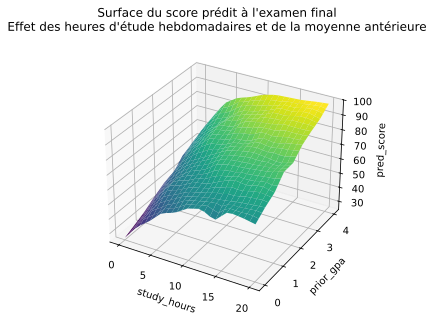

In [2]:
GOPTIONS reset=GLOBAL BORDER;

TITRE "Surface du score prédit à l'examen final";
title2 "Effet des heures d'étude hebdomadaires et de la moyenne antérieure";
footnote j=r "Données synthétiques d'analytique éducative ";

PROCÉDURE g3d DONNÉES=score_grid;
   PLOT prior_gpa*study_hours=pred_score;
   ÉTIQUETTE study_hours = "Heures d'étude hebdomadaires"
         prior_gpa   = 'Moyenne académique antérieure'
         pred_score  = "Score d'examen prédit";
EXÉCUTER;
QUIT;


## Étape 3 — Affiner la surface avec des options de vue et d'axes

Quelques options rendent la surface bien plus lisible :

- **ROTATE=** et **TILT=** définissent l'angle de vue (degrés autour de
  l'axe Z, et inclinaison vers l'observateur).
- **XYTYPE=2** trace les lignes de surface parallèles à l'axe Y, mettant en
  valeur la façon dont le score grimpe avec les heures d'étude.
- **SIDE** ajoute une paroi latérale pour un rendu plein et sculpté.
- **GRID** ajoute des lignes de repère aux graduations principales.
- **ZMIN=/ZMAX=** et la famille **ZTICKNUM=** fixent l'axe du score sur la
  plage complète de 0 à 100 afin que la surface ne soit pas visuellement
  exagérée, tandis que **XTICKNUM=/YTICKNUM=** contrôlent les graduations du
  plan du sol.
- **NAME=** et **DESCRIPTION=** identifient le graphique dans le catalogue
  de sortie.


                                    Surface du score d'examen prédit (vue stylisée)                                     
                                     Rotation, inclinaison et axes mis à l'échelle                                      

PROC G3D Output
Data: score_grid

Variables: Heures d'étude hebdomadaires, Moyenne académique antérieure, Score d'examen prédit

 Heures d'étude hebdomadaires    Moyenne académique antérieure   Score d'examen prédit
-----------------------------  -------------------------------  ----------------------
                            0                                0           25.7031536911
                            0                              0.5           28.9516502743
                            0                                1           32.3400787822
                            0                              1.5           36.8265757618
                            0                                2           40.7806886968
                   


NOTE: Option TITLE changed to Surface du score d'examen prédit (vue stylisée).
NOTE: Option TITLE2 changed to Rotation, inclinaison et axes mis à l'échelle.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: scoresurf.spec.json


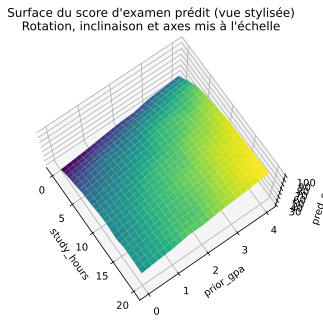

In [3]:
TITRE "Surface du score d'examen prédit (vue stylisée)";
title2 "Rotation, inclinaison et axes mis à l'échelle";

PROCÉDURE g3d DONNÉES=score_grid;
   PLOT prior_gpa*study_hours=pred_score /
        ROTATE=55
        tilt=75
        xytype=2
        side
        grid
        zmin=0 zmax=100
        xticknum=5 yticknum=5 zticknum=6
        name="scoresurf"
        description="Surface de réponse stylisée du score d'examen";
   ÉTIQUETTE study_hours = "Heures d'étude hebdomadaires"
         prior_gpa   = 'Moyenne académique antérieure'
         pred_score  = "Score d'examen prédit";
EXÉCUTER;
QUIT;


## Étape 4 — Comparer la surface sous plusieurs angles de vue

Comme une surface 3D peut cacher de la structure derrière ses propres
sommets, il est utile de rendre la même surface sous plus d'une rotation.
Nous exécutons ici trois étapes PROC G3D qui partagent une inclinaison fixe
mais font varier l'angle **ROTATE=** à 30, 90 et 150 degrés, afin que la
crête puisse être inspectée de face, de côté et de dos.


                                                   Surface de réponse                                                   
                                             ROTATE = 30 à inclinaison fixe                                             

PROC G3D Output
Data: score_grid

Variables: Heures d'étude hebdomadaires, Moyenne académique antérieure, Score d'examen prédit

 Heures d'étude hebdomadaires    Moyenne académique antérieure   Score d'examen prédit
-----------------------------  -------------------------------  ----------------------
                            0                                0           25.7031536911
                            0                              0.5           28.9516502743
                            0                                1           32.3400787822
                            0                              1.5           36.8265757618
                            0                                2           40.7806886968
                   


NOTE: Option TITLE changed to Surface de réponse.
NOTE: Option TITLE2 changed to ROTATE = 30 à inclinaison fixe.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot30.spec.json
NOTE: Option TITLE changed to Surface de réponse.
NOTE: Option TITLE2 changed to ROTATE = 90 à inclinaison fixe.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot90.spec.json
NOTE: Option TITLE changed to Surface de réponse.
NOTE: Option TITLE2 changed to ROTATE = 150 à inclinaison fixe.
NOTE: PROC G3D data=score_grid

NOTE: ODS plot written: surf_rot150.spec.json


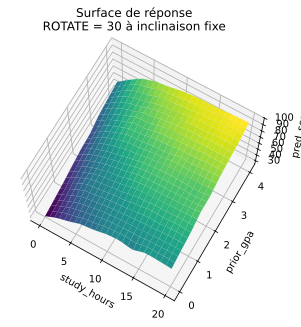

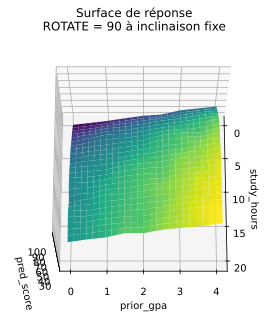

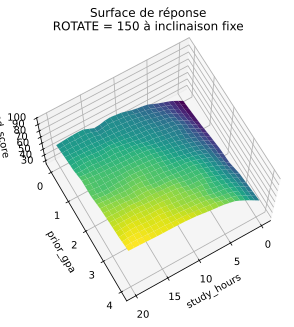

In [4]:
%macro angle(deg);
   TITRE 'Surface de réponse';
   title2 "ROTATE = &deg à inclinaison fixe";
   PROCÉDURE g3d DONNÉES=score_grid;
      PLOT prior_gpa*study_hours=pred_score /
           ROTATE=&deg
           tilt=70
           xytype=3
           zmin=0 zmax=100
           name="surf_rot&deg";
      ÉTIQUETTE study_hours = "Heures d'étude hebdomadaires"
            prior_gpa   = 'Moyenne académique antérieure'
            pred_score  = "Score d'examen prédit";
   EXÉCUTER;
   QUIT;
%mend;

%angle(30);
%angle(90);
%angle(150);


## Étape 5 — Générer une cohorte synthétique d'étudiants

La surface est un modèle ; les étudiants réels se dispersent autour d'elle.
Nous simulons maintenant 100 étudiants individuels tirés de deux cohortes
d'inscription (`Automne`, `Printemps`). Chaque étudiant a des heures
d'étude observées, une moyenne antérieure, et un score d'examen réalisé
bruité généré à partir de la même logique de réponse plus une variation
individuelle plus importante.

Nous dérivons ensuite un **palier** de réussite à partir du score d'examen :
`Excellent` (85 ou plus), `Réussite` (65 à 84), et `Fragile` (moins de 65).
Le tableau croisé PROC FREQ ci-dessous indique comment les paliers se
répartissent entre les deux cohortes. `rand('UNIFORM')` et `rand('NORMAL')`
fournissent l'aléa ; la graine garantit la reproductibilité.


                                                   Surface de réponse                                                   
                                            ROTATE = 150 à inclinaison fixe                                             

                                                   The FREQ Procedure

                                    Cumulative
Palier de réussite     Frequency    Frequency
-------------------------------------------------
Excellent                     20           20
Fragile                       33           53
Réussite                      47          100

Table of Cohorte by Palier de réussite

Cohorte   | Excellent |   Fragile |  Réussite |      Total
----------+-----------+-----------+-----------+-----------
Automne   |         6 |        15 |        20 |         41
----------+-----------+-----------+-----------+-----------
Printemps |        14 |        18 |        27 |         59
----------+-----------+-----------+-----------+-----------
Total     


NOTE: DATA students


NOTE: Wrote students (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_band.spec.json
NOTE: ODS plot written: freq_mosaic_cohort_band.spec.json
NOTE: PROC FREQ statement used.


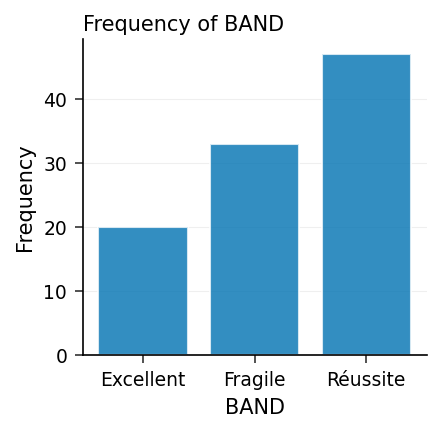

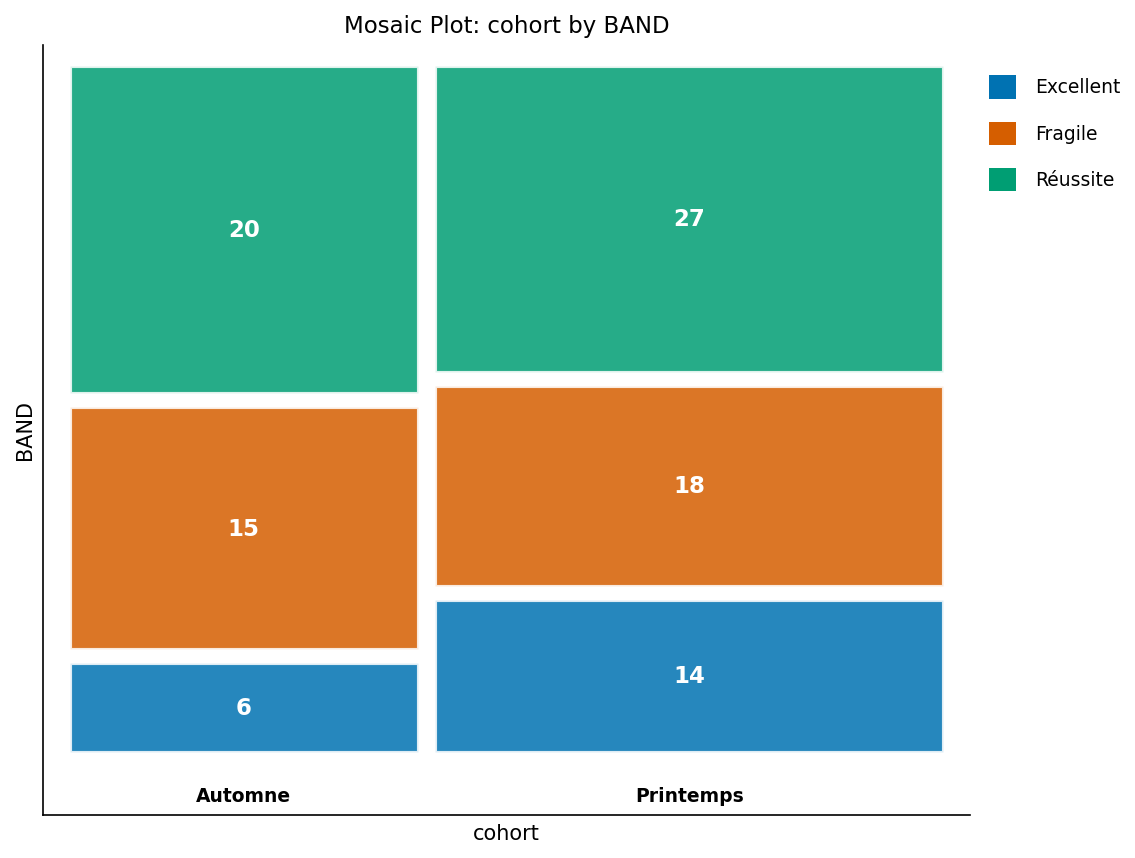

In [5]:
DONNÉES students;
   APPELER streaminit(99001);
   LONGUEUR cohort $10 BAND $10;
   FAIRE student_id = 1 JUSQU_À 100;
      SI rand('UNIFORM') < 0.5 ALORS cohort = 'Automne';
      SINON cohort = 'Printemps';

      study_hours = 20 * rand('UNIFORM');
      prior_gpa   = 4  * rand('UNIFORM');

      effort = 40 * (1 - EXP(-study_hours / 6));
      BASE   = 8 * prior_gpa;
      inter  = 1.1 * prior_gpa * (1 - EXP(-study_hours / 6));
      exam_score = 25 + effort + BASE + inter
                   + rand('NORMAL') * 7;
      SI exam_score > 100 ALORS exam_score = 100;
      SI exam_score < 0   ALORS exam_score = 0;

      SI exam_score >= 85 ALORS BAND = 'Excellent';
      SINON SI exam_score >= 65 ALORS BAND = 'Réussite';
      SINON BAND = 'Fragile';

      SORTIE;
   FIN;
   GARDER student_id cohort study_hours prior_gpa exam_score BAND;
EXÉCUTER;

PROCÉDURE FRÉQUENCES DONNÉES=students;
   TABLES BAND cohort*BAND / nocol nopercent;
   ÉTIQUETTE cohort="Cohorte" BAND="Palier de réussite";
EXÉCUTER;


## Étape 6 — Tracer les étudiants en nuages de points 3D par palier de réussite

L'instruction **SCATTER** place chaque étudiant comme un symbole 3D. Pour
rendre les trois paliers de réussite faciles à lire, nous traçons un
panneau par palier, chacun filtré avec **WHERE** et doté de son propre
**COLOR=** et **SHAPE=** littéraux : des losanges verts (`SHAPE=diamond`)
pour *Excellent*, des marqueurs bleus (`SHAPE=club`) pour *Réussite*, et des
marqueurs rouges (`SHAPE=spade`) pour *Fragile*. **SIZE=** agrandit les
marqueurs, **GRID** ajoute des lignes de repère au sol, **NONEEDLE**
supprime les lignes de chute verticales, et **ZMIN=/ZMAX=** maintiennent
chaque panneau sur le même axe de score de 0 à 100 afin que les trois vues
soient directement comparables.

Chaque palier reçoit sa propre étape PROC G3D afin que son filtre WHERE
s'applique proprement et que le style de marqueur soit sans ambiguïté.


                                                  Étudiants Excellent                                                   
                                               Score d'examen 85 et plus                                                

PROC G3D Output
Data: students

Variables: student_id, cohort, Heures d'étude hebdomadaires, Moyenne académique antérieure, Score d'examen final, BAND

student_id      cohort   Heures d'étude hebdomadaires    Moyenne académique antérieure  Score d'examen final        BAND
----------  ----------  -----------------------------  -------------------------------  --------------------  ----------
         2   Printemps                  19.2134883194                     2.6467742616         90.3663886999   Excellent
         5   Printemps                  15.5520919174                     2.7102003827         94.9419468332   Excellent
        10   Printemps                  14.2302640951                     3.8791496428                   100   Excellent



NOTE: Option FOOTNOTE changed to Issu d'une cohorte de 100 étudiants synthétiques .
NOTE: Option TITLE changed to Étudiants Excellent.
NOTE: Option TITLE2 changed to Score d'examen 85 et plus.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_honors.spec.json
NOTE: Option TITLE changed to Étudiants Réussite.
NOTE: Option TITLE2 changed to Score d'examen de 65 à 84.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_pass.spec.json
NOTE: Option TITLE changed to Étudiants Fragile.
NOTE: Option TITLE2 changed to Score d'examen inférieur à 65.
NOTE: PROC G3D data=students

NOTE: ODS plot written: band_atrisk.spec.json


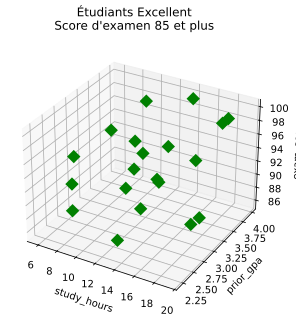

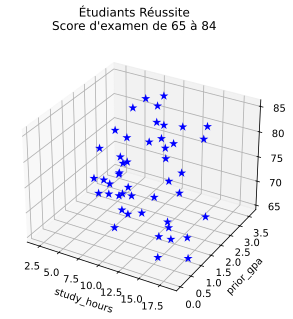

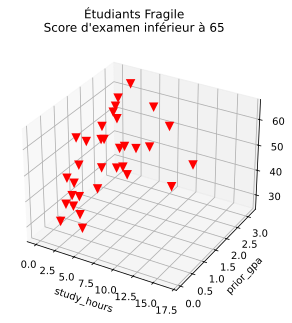

In [6]:
footnote j=r "Issu d'une cohorte de 100 étudiants synthétiques ";

/* Excellent (exam_score >= 85) : losanges verts */
TITRE 'Étudiants Excellent';
title2 "Score d'examen 85 et plus";
PROCÉDURE g3d DONNÉES=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=green shape=diamond size=3
           noneedle grid zmin=0 zmax=100
           name="band_honors"
           description="Étudiants du palier Excellent";
   OÙ BAND = 'Excellent';
   ÉTIQUETTE study_hours = "Heures d'étude hebdomadaires"
         prior_gpa   = 'Moyenne académique antérieure'
         exam_score  = "Score d'examen final";
EXÉCUTER;
QUIT;

/* Réussite (65 <= exam_score < 85) : trèfles bleus */
TITRE 'Étudiants Réussite';
title2 "Score d'examen de 65 à 84";
PROCÉDURE g3d DONNÉES=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=blue shape=club size=3
           noneedle grid zmin=0 zmax=100
           name="band_pass"
           description="Étudiants du palier Réussite";
   OÙ BAND = 'Réussite';
   ÉTIQUETTE study_hours = "Heures d'étude hebdomadaires"
         prior_gpa   = 'Moyenne académique antérieure'
         exam_score  = "Score d'examen final";
EXÉCUTER;
QUIT;

/* Fragile (exam_score < 65) : piques rouges */
TITRE 'Étudiants Fragile';
title2 "Score d'examen inférieur à 65";
PROCÉDURE g3d DONNÉES=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red shape=spade size=3
           noneedle grid zmin=0 zmax=100
           name="band_atrisk"
           description="Étudiants du palier Fragile";
   OÙ BAND = 'Fragile';
   ÉTIQUETTE study_hours = "Heures d'étude hebdomadaires"
         prior_gpa   = 'Moyenne académique antérieure'
         exam_score  = "Score d'examen final";
EXÉCUTER;
QUIT;


## Étape 7 — Nuages de points séparés par cohorte d'inscription (groupe BY)

Les responsables de programme ont souvent besoin de la même vue répartie
par cohorte. L'instruction **BY** produit un nuage de points par cohorte.
G3D attend que les données du groupe BY soient triées, nous trions donc
d'abord avec PROC SORT. Chaque cohorte reçoit ensuite son propre nuage de
points 3D étiqueté sur un axe de score partagé de 0 à 100, ce qui permet de
comparer facilement les distributions Automne et Printemps côte à côte.


                                      Résultats d'examen par cohorte d'inscription                                      
                                 Un nuage de points 3D par cohorte (Automne, Printemps)                                 

PROC G3D Output
Data: students_sorted

Variables: student_id, cohort, Heures d'étude hebdomadaires, Moyenne académique antérieure, Score d'examen final, BAND

student_id      cohort   Heures d'étude hebdomadaires    Moyenne académique antérieure  Score d'examen final        BAND
----------  ----------  -----------------------------  -------------------------------  --------------------  ----------
        52     Automne                  15.2586640362                     0.4602308374         55.5186804916     Fragile
        13     Automne                   5.8493366471                     1.8449001873         70.6084324429    Réussite
        15     Automne                   5.5070892672                     1.4478111608         70.0069314398    Ré


NOTE: PROC SORT data=students

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from students.
NOTE: Wrote students_sorted (100 rows, 6 columns).
NOTE: PROC SORT statement used.
NOTE: Option TITLE changed to Résultats d'examen par cohorte d'inscription.
NOTE: Option TITLE2 changed to Un nuage de points 3D par cohorte (Automne, Printemps).
NOTE: Option FOOTNOTE changed to Un panneau par cohorte .
NOTE: PROC G3D data=students_sorted

NOTE: ODS plot written: cohort_scatter_by1.spec.json
NOTE: ODS plot written: cohort_scatter_by2.spec.json


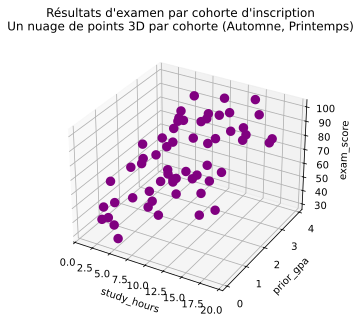

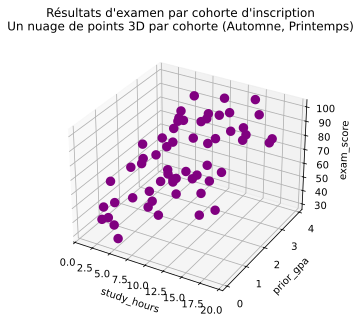

In [7]:
PROCÉDURE TRIER DONNÉES=students out=students_sorted;
   PAR cohort;
EXÉCUTER;

TITRE "Résultats d'examen par cohorte d'inscription";
title2 'Un nuage de points 3D par cohorte (Automne, Printemps)';
footnote j=r 'Un panneau par cohorte ';

PROCÉDURE g3d DONNÉES=students_sorted;
   PAR cohort;
   SCATTER prior_gpa*study_hours=exam_score /
           color=purple
           shape=balloon
           size=3
           grid
           zmin=0 zmax=100
           name="cohort_scatter";
   ÉTIQUETTE study_hours = "Heures d'étude hebdomadaires"
         prior_gpa   = 'Moyenne académique antérieure'
         exam_score  = "Score d'examen final";
EXÉCUTER;
QUIT;


## Étape 8 — Se concentrer sur la région à risque avec WHERE

Pour la planification d'interventions, la vue la plus actionnable est le
coin inférieur gauche de la surface : les étudiants avec à la fois un temps
d'étude modeste (8 heures ou moins) et une moyenne antérieure plus faible
(2,5 ou moins). L'instruction **WHERE** restreint le nuage de points à
cette région avant le tracé. Le listing montre que ce coin regroupe 35 des
100 étudiants — 22 d'entre eux déjà *Fragile* — permettant ainsi aux
conseillers de voir précisément quels étudiants en difficulté se situent le
plus loin en dessous des attentes.


                          Ciblage d'intervention : étudiants à faible effort et faible moyenne                          
                                          study_hours <= 8 et prior_gpa <= 2.5                                          

PROC G3D Output
Data: students

Variables: student_id, cohort, Heures d'étude hebdomadaires, Moyenne académique antérieure, Score d'examen final, BAND

student_id      cohort   Heures d'étude hebdomadaires    Moyenne académique antérieure  Score d'examen final        BAND
----------  ----------  -----------------------------  -------------------------------  --------------------  ----------
         1     Automne                   4.9780700766                      1.072086769          59.409228777     Fragile
         7   Printemps                   7.9015823058                     1.6623636789         66.9055021729    Réussite
         9   Printemps                   2.5008494545                     0.3621033759         48.1183184446     Fragile



NOTE: Option TITLE changed to Ciblage d'intervention : étudiants à faible effort et faible moyenne.
NOTE: Option TITLE2 changed to study_hours <= 8 et prior_gpa <= 2.5.
NOTE: Option FOOTNOTE changed to Les aiguilles relient chaque marqueur au plan heures d'étude x moyenne .
NOTE: PROC G3D data=students

NOTE: ODS plot written: g3d_scatter.spec.json


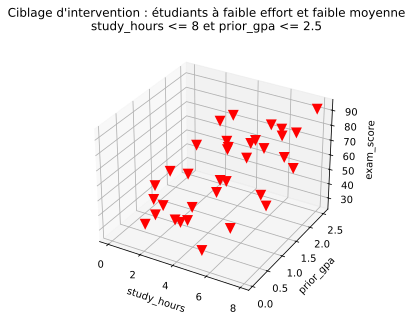

In [8]:
TITRE "Ciblage d'intervention : étudiants à faible effort et faible moyenne";
title2 'study_hours <= 8 et prior_gpa <= 2.5';
footnote j=r "Les aiguilles relient chaque marqueur au plan heures d'étude x moyenne ";

PROCÉDURE g3d DONNÉES=students;
   SCATTER prior_gpa*study_hours=exam_score /
           color=red
           shape=spade
           size=4
           grid
           zmin=0 zmax=100;
   OÙ study_hours <= 8 AND prior_gpa <= 2.5;
   ÉTIQUETTE study_hours = "Heures d'étude hebdomadaires"
         prior_gpa   = 'Moyenne académique antérieure'
         exam_score  = "Score d'examen final";
EXÉCUTER;
QUIT;


## Interprétation des résultats

La **surface de réponse** (étapes 2 à 4) montre une crête de saturation
nette. Sur la grille de 99 cellules, le score prédit va d'environ 26 (zéro
heure d'étude, moyenne nulle) jusqu'à environ 99 (le coin heures élevées,
moyenne élevée), avec une moyenne globale de la grille proche de 70. En
lisant le long de l'axe des heures d'étude, les scores montent fortement de
0 vers environ 10 heures puis s'aplatissent à mesure que les heures
supplémentaires produisent des rendements décroissants ; en lisant le long
de l'axe de la moyenne, la réussite antérieure décale toute la surface vers
le haut. Le terme d'interaction rend le gain lié aux heures d'étude un peu
plus marqué pour les étudiants plus forts, ce qui explique pourquoi la
surface s'incline vers son coin lointain plutôt que de s'élever comme un
plan plat.

Les **panneaux d'étudiants** (étapes 6 à 7) confirment que le modèle tient
au niveau individuel. La cohorte de 100 se répartit en 20 étudiants
*Excellent*, 47 *Réussite*, et 33 *Fragile*. Dans les panneaux par palier,
les 20 losanges verts *Excellent* — chacun avec un score de 85 ou plus — se
situent à une moyenne antérieure de 2,2 ou plus et à au moins environ 6
heures d'étude hebdomadaires, regroupés dans le coin supérieur droit du plan
du sol. Les 33 marqueurs rouges *Fragile* se concentrent dans la région à
faible effort et faible moyenne, précisément la vallée de la surface. La
répartition par cohorte montre que les distributions Automne (41 étudiants)
et Printemps (59 étudiants) sont globalement similaires, ce qui suggère que
les résultats sont déterminés par les deux facteurs plutôt que par le moment
de l'inscription.

La **vue filtrée par WHERE** (étape 8) isole la population cible de
l'intervention : les 35 étudiants avec 8 heures d'étude ou moins et une
moyenne de 2,5 ou moins. Vingt-deux sont déjà *Fragile* et un seul atteint
*Excellent*. Dans ce coin, les scores réalisés grimpent tout de même
visiblement avec les heures d'étude — un argument visuel concret montrant
que des hausses modestes du temps d'étude structuré offrent les gains
marginaux les plus importants précisément là où ils sont le plus
nécessaires.

Pris ensemble, PROC G3D transforme un modèle d'interaction à deux facteurs
en une image intuitive et exploitable pour la décision au sein d'un
programme éducatif : où se situe le plafond du score, qui reste en deçà, et
où l'effort d'accompagnement rapportera le plus.

> **Note d'implémentation.** SAS/GRAPH permet aussi à une seule instruction
> SCATTER de colorer et de façonner chaque marqueur à partir de variables
> par observation (`COLOR=<charvar>`, `SHAPE=<charvar>`). Cette forme par
> observation ne se rend pas encore dans ce moteur, si bien que ce notebook
> trace à la place un panneau à couleur littérale par palier — une
> présentation équivalente et pleinement fonctionnelle. Cet écart est suivi
> par le test de régression archivé
> `tests/401000_nb_g3d_scatter_color_variable_unrendered`.
